In [1123]:
# %pip install pandas 
#%pip install matplotlib
# %pip install statsmodels
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.optimize import curve_fit
from statsmodels.tsa.stattools import adfuller
import scipy.signal as scs
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.tsa.stattools as st

In [1124]:
dataset = pd.read_csv('CPITimeSeries.csv',low_memory=False)
dataset.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Attribute,1950M1,1950M2,1950M3,1950M4,1950M5,...,2022M1,2022M2,2022M3,2022M4,2022M5,2022M6,2022M7,2022M8,Common Reference Period,Unnamed: 878
0,Brazil,223,"Consumer Price Index, All items, Percentage ch...",PCPI_PC_PP_PT,Value,NaN,NaN,NaN,NaN,NaN,...,0.540029150136277,1.01006161132049,1.62005007047194,1.06001808126436,0.470007269445767,0.670057758760498,-0.680003407761961,NaN,NaN,NaN
1,Brazil,223,"Consumer Price Index, All items, Percentage ch...",PCPI_PC_CP_A_PT,Value,NaN,NaN,NaN,NaN,NaN,...,10.3794248442458,10.5436617263354,11.2994121295852,12.1316302169067,11.731212845584,11.886869625198,10.0694033168709,NaN,NaN,NaN
2,Brazil,223,Communication,PCPIEC_IX,Value,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1993M12,NaN
3,Brazil,223,Communication,PCPIEC_IX,Reference Period,NaN,NaN,NaN,NaN,NaN,...,1993M12,1993M12,1993M12,1993M12,1993M12,1993M12,1993M12,NaN,NaN,NaN
4,Brazil,223,Clothing and footwear,PCPIA_IX,Value,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1993M12,NaN


In [1125]:
# Filter the dataset to keep only rows where "Attribute" is "Value"
dataset = dataset[dataset['Attribute'] == 'Value']
dataset.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Attribute,1950M1,1950M2,1950M3,1950M4,1950M5,...,2022M1,2022M2,2022M3,2022M4,2022M5,2022M6,2022M7,2022M8,Common Reference Period,Unnamed: 878
0,Brazil,223,"Consumer Price Index, All items, Percentage ch...",PCPI_PC_PP_PT,Value,NaN,NaN,NaN,NaN,NaN,...,0.540029150136277,1.01006161132049,1.62005007047194,1.06001808126436,0.470007269445767,0.670057758760498,-0.680003407761961,NaN,NaN,NaN
1,Brazil,223,"Consumer Price Index, All items, Percentage ch...",PCPI_PC_CP_A_PT,Value,NaN,NaN,NaN,NaN,NaN,...,10.3794248442458,10.5436617263354,11.2994121295852,12.1316302169067,11.731212845584,11.886869625198,10.0694033168709,NaN,NaN,NaN
2,Brazil,223,Communication,PCPIEC_IX,Value,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1993M12,NaN
4,Brazil,223,Clothing and footwear,PCPIA_IX,Value,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1993M12,NaN
6,France,132,"Restaurants and hotels, Weight",PCPIRE_WT,Value,NaN,NaN,NaN,NaN,NaN,...,66,66,66,66,66,66,66,66,NaN,NaN


In [1126]:
# Select only the columns whose names follow the "YYYYM#" format,
# meaning 4 digits for the year + 'M' + the month number.
year_columns = dataset.columns[dataset.columns.str.match(r'^\d{4}M\d+$')]
year_columns

# Extract only the years (the first 4 digits of the column names)
years = year_columns.str[:4].astype(int)

# Show only the years that are out of order
# diff() < 0 indicates a decrease, meaning the order is not increasing
out_of_order_years = years[years.diff().fillna(1) < 0]  

In [1127]:
# Extract year and month from the column names
year_month = year_columns.str.extract(r'(?P<Year>\d{4})M(?P<Month>\d{1,2})')
year_month['Year'] = year_month['Year'].astype(int)
year_month['Month'] = year_month['Month'].astype(int)

# Check for months that are out of order within each year
# diff() < 0 indicates a decrease in the sequence
months_out_of_order = year_month.groupby('Year')['Month'].apply(lambda x: x[x.diff().fillna(1) < 0])

print("Months out of order by year:")
print(months_out_of_order)

Months out of order by year:
Series([], Name: Month, dtype: int64)


In [1128]:
# Keep only the columns with year >= 1990
year_columns_1990_onwards = year_columns[year_columns.str[:4].astype(int) >= 1990]

# Display the filtered columns
year_columns_1990_onwards

Index(['1990M1', '1990M2', '1990M3', '1990M4', '1990M5', '1990M6', '1990M7',
       '1990M8', '1990M9', '1990M10',
       ...
       '2021M11', '2021M12', '2022M1', '2022M2', '2022M3', '2022M4', '2022M5',
       '2022M6', '2022M7', '2022M8'],
      dtype='str', length=392)

In [1129]:
year_filter_data = dataset[["Country Name","Indicator Name", "Indicator Code",] + list(year_columns_1990_onwards)]
year_filter_data.head()

,Country Name,Indicator Name,Indicator Code,1990M1,1990M2,1990M3,1990M4,1990M5,1990M6,1990M7,...,2021M11,2021M12,2022M1,2022M2,2022M3,2022M4,2022M5,2022M6,2022M7,2022M8
0,Brazil,"Consumer Price Index, All items, Percentage ch...",PCPI_PC_PP_PT,67.5500201585559,75.7299998872637,82.3899860535296,15.5199783192206,7.59000524605285,11.7500127582383,12.920002092382,...,0.950069037020781,0.729958243425856,0.540029150136277,1.01006161132049,1.62005007047194,1.06001808126436,0.470007269445767,0.670057758760498,-0.680003407761961,NaN
1,Brazil,"Consumer Price Index, All items, Percentage ch...",PCPI_PC_CP_A_PT,2426.12066594988,3701.29520297563,6390.52873938333,6821.30914769282,6214.99288949151,5385.4302602777,4749.02826788979,...,10.7385009076792,10.0609827374433,10.3794248442458,10.5436617263354,11.2994121295852,12.1316302169067,11.731212845584,11.886869625198,10.0694033168709,NaN
2,Brazil,Communication,PCPIEC_IX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Brazil,Clothing and footwear,PCPIA_IX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,France,"Restaurants and hotels, Weight",PCPIRE_WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,59.9,59.9,66,66,66,66,66,66,66,66


In [1130]:
# Filter year_filter_data to keep only rows where Indicator Code is 'PCPI_IX'
pcpi_ix_data = year_filter_data[year_filter_data["Indicator Code"] == "PCPI_IX"]
pcpi_ix_data.head()

,Country Name,Indicator Name,Indicator Code,1990M1,1990M2,1990M3,1990M4,1990M5,1990M6,1990M7,...,2021M11,2021M12,2022M1,2022M2,2022M3,2022M4,2022M5,2022M6,2022M7,2022M8
17,Brazil,"Consumer Price Index, All items",PCPI_IX,0.005410857,0.009508499,0.01734255,0.02003411,0.0215547,0.02408738,0.02719947,...,6075.69,6120.04,6153.09,6215.24,6315.93,6382.88,6412.88,6455.85,6411.95,NaN
30,France,"Consumer Price Index, All items",PCPI_IX,66.42,66.56,66.72,67.09,67.19,67.18,67.2,...,107.64,107.85,108.12,108.94,110.49,110.97,111.72,112.55,112.87,113.29
104,Bulgaria,"Consumer Price Index, All items",PCPI_IX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7659.2699399122,7728.99879117314,7841.08640403034,7954.55523691129,8131.17796924526,8331.52722236692,8432.65279081599,8506.69398844988,8601.91208943529,8702.17132815588
154,Honduras,"Consumer Price Index, All items",PCPI_IX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,365,368.5,373,374.3,377.8,384.2,387.6,392.7,396.2,396.1
173,Colombia,"Consumer Price Index, All items",PCPI_IX,5.967753,6.191108,6.372583,6.547079,6.679696,6.805333,6.89607,...,110.6031,111.4066,113.2623,115.1129,116.2593,117.7089,118.7032,119.3053,120.2736,121.5025


In [1131]:
# Remove the columns "Indicator Name" and "Indicator Code" from pcpi_ix_data
pcpi_ix_data = pcpi_ix_data.drop(columns=['Indicator Name', 'Indicator Code'])
pcpi_ix_data.head()

,Country Name,1990M1,1990M2,1990M3,1990M4,1990M5,1990M6,1990M7,1990M8,1990M9,...,2021M11,2021M12,2022M1,2022M2,2022M3,2022M4,2022M5,2022M6,2022M7,2022M8
17,Brazil,0.005410857,0.009508499,0.01734255,0.02003411,0.0215547,0.02408738,0.02719947,0.03070276,0.03512703,...,6075.69,6120.04,6153.09,6215.24,6315.93,6382.88,6412.88,6455.85,6411.95,NaN
30,France,66.42,66.56,66.72,67.09,67.19,67.18,67.2,67.64,68.12,...,107.64,107.85,108.12,108.94,110.49,110.97,111.72,112.55,112.87,113.29
104,Bulgaria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7659.2699399122,7728.99879117314,7841.08640403034,7954.55523691129,8131.17796924526,8331.52722236692,8432.65279081599,8506.69398844988,8601.91208943529,8702.17132815588
154,Honduras,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,365,368.5,373,374.3,377.8,384.2,387.6,392.7,396.2,396.1
173,Colombia,5.967753,6.191108,6.372583,6.547079,6.679696,6.805333,6.89607,7.007748,7.175263,...,110.6031,111.4066,113.2623,115.1129,116.2593,117.7089,118.7032,119.3053,120.2736,121.5025


In [1132]:
# Count null values per country (row) and sort from least to most
null_counts = pcpi_ix_data.isna().sum(axis=1).sort_values()

# Create a dataframe with results including country names
null_summary = pd.DataFrame({
    'Country': pcpi_ix_data.loc[null_counts.index, 'Country Name'].values,
    'Null Count': null_counts.values,
    'Total Columns': len(pcpi_ix_data.columns) - 1,  # -1 porque 'Country Name' não é um valor
    'Null Percentage': (null_counts.values / (len(pcpi_ix_data.columns) - 1) * 100).round(2)
})

print(f"Countries with null values - Sorted from least to most nulls:\n")
print(null_summary.to_string(index=False))

Countries with null values - Sorted from least to most nulls:

                                 Country  Null Count  Total Columns  Null Percentage
                                  France           0            392             0.00
                                Colombia           0            392             0.00
                                 Finland           0            392             0.00
                                 Germany           0            392             0.00
                                 Iceland           0            392             0.00
                                 Denmark           0            392             0.00
                                  Greece           0            392             0.00
                                 Austria           0            392             0.00
                                   Chile           0            392             0.00
                                 Belgium           0            392             0.00
  

In [1133]:
hungary_data = pcpi_ix_data[pcpi_ix_data['Country Name'] == 'Hungary']
hungary_data.head()

,Country Name,1990M1,1990M2,1990M3,1990M4,1990M5,1990M6,1990M7,1990M8,1990M9,...,2021M11,2021M12,2022M1,2022M2,2022M3,2022M4,2022M5,2022M6,2022M7,2022M8
1083,Hungary,9.967114,10.46182,10.68106,10.89468,10.91717,10.9003,11.24322,11.49057,11.69295,...,164.5,164.9,167.2,169,170.7,173.4,176.3,178.9,183.1,186.4


In [1134]:
hungary_values = hungary_data.iloc[:, 1:]

ts_hungary = hungary_values.T
ts_hungary.columns = ['CPI']

#Converter o index para o formato de data 
ts_hungary.index = pd.to_datetime(ts_hungary.index, format='%YM%m')

ts_hungary.shape

(392, 1)

In [1135]:
split_point = int(len(ts_hungary) * 0.70)

train = ts_hungary.iloc[:split_point]

test = ts_hungary.iloc[split_point:]

print(f"Total m: {len(ts_hungary)}")
print(f"train (70%): {len(train)} m")
print(f"test (30%): {len(test)} m")

Total m: 392
train (70%): 274 m
test (30%): 118 m


In [1136]:
# reset ind
train_TS = train.reset_index()

train_TS.columns = ['Date', 'CPI']

# CPI numeric
train_TS['CPI'] = pd.to_numeric(train_TS['CPI'], errors='coerce')
print(train_TS.head())

        Date        CPI
0 1990-01-01   9.967114
1 1990-02-01  10.461820
2 1990-03-01  10.681060
3 1990-04-01  10.894680
4 1990-05-01  10.917170


# Etapa 1- Descrição

## Plotar a série para avaliar trend e sazonalidade

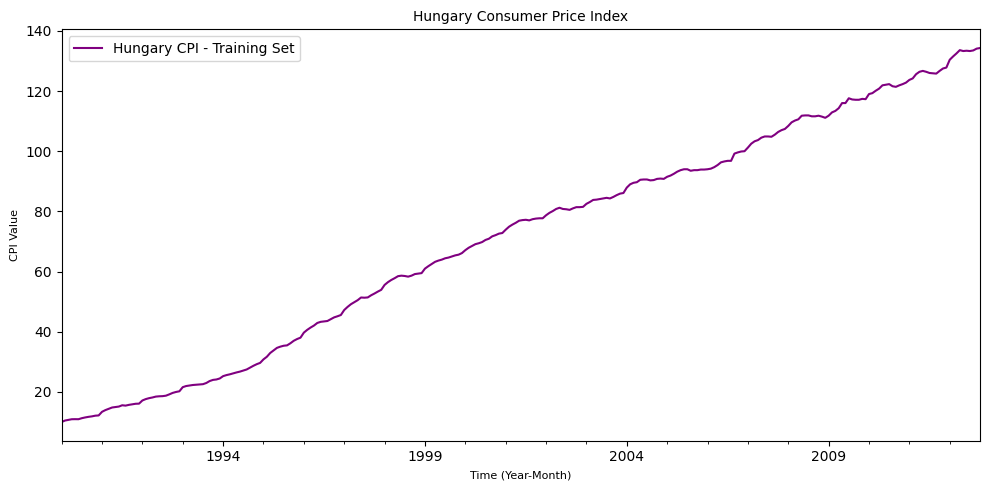

Date
1990-01-01     9.967114
1990-02-01    10.461820
1990-03-01    10.681060
1990-04-01    10.894680
1990-05-01    10.917170
Name: Hungary CPI - Training Set, dtype: float64


In [1137]:
train_df = train.reset_index()
train_df.columns = ['Date', 'CPI']
train_df['CPI'] = pd.to_numeric(train_df['CPI'], errors='coerce')

train_TS = pd.Series(
    data=np.array(train_df["CPI"]), 
    index=train_df["Date"], 
    name="Hungary CPI - Training Set"
)

fig, ax = plt.subplots(figsize=(10, 5))

train_TS.plot(ax=ax, legend=True, color='purple') 

ax.set_ylabel('CPI Value', fontdict={'fontsize': 8})
ax.set_xlabel('Time (Year-Month)', fontdict={'fontsize': 8})
ax.set_title('Hungary Consumer Price Index', fontsize=10)

plt.tight_layout()
plt.show()

print(train_TS.head())

A série tem tendência para crescer e apenas pelo plot não se percebe um padrão sazonal claro.

Modelos linear e quadrático:

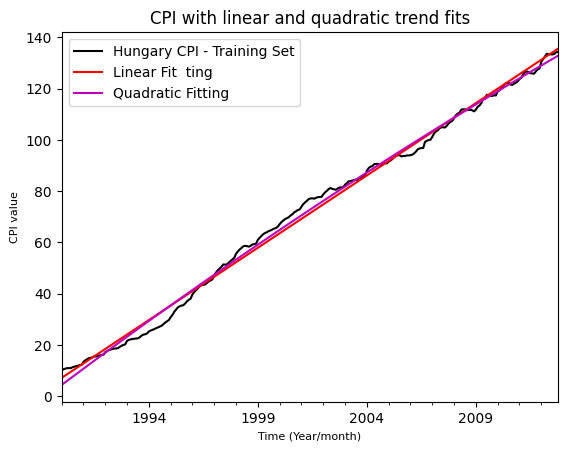

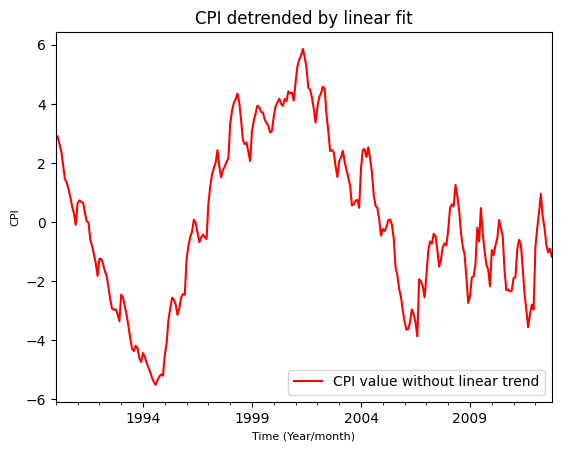

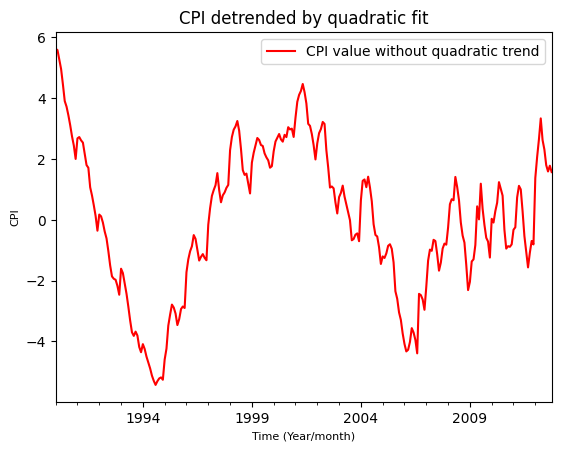

In [1138]:
tMonths = np.arange(len(train_TS))

# Linear trend estimation by fitting
coefs_lin = np.polyfit(tMonths, train_TS.values, 1)
linVals = np.polyval(coefs_lin, tMonths)
linTS = pd.Series(data=linVals, index=train_TS.index, name="Linear Fit  ting")

# Quadratic trend estimation by fitting
coefs_quad = np.polyfit(tMonths, train_TS.values, 2)
quadVals = np.polyval(coefs_quad, tMonths)
quadTS = pd.Series(data=quadVals, index=train_TS.index, name="Quadratic Fitting")

plt.figure()
ax = train_TS.plot(legend=True, color='k')
linTS.plot(ax=ax, legend=True, color='r')
quadTS.plot(ax=ax, legend=True, color='m')
ax.set_ylabel('CPI value', fontdict={'fontsize': 8})
ax.set_xlabel('Time (Year/month)', fontdict={'fontsize': 8})
ax.set_title('CPI with linear and quadratic trend fits')
plt.show()

# Remove linear trend
plt.figure()
ts_no_trend__lin_addict = train_TS - linTS
ts_no_trend__lin_addict.name = "CPI value without linear trend"
ax2 = ts_no_trend__lin_addict.plot(legend=True, color='r')
ax2.set_ylabel('CPI', fontdict={'fontsize': 8})
ax2.set_xlabel('Time (Year/month)', fontdict={'fontsize': 8})
ax2.set_title('CPI detrended by linear fit')
plt.show()

# Remove quadratic trend
plt.figure()
ts_no_trend__quad_addict = train_TS - quadTS
ts_no_trend__quad_addict.name = "CPI value without quadratic trend"
ax3 = ts_no_trend__quad_addict.plot(legend=True, color='r')
ax3.set_ylabel('CPI', fontdict={'fontsize': 8})
ax3.set_xlabel('Time (Year/month)', fontdict={'fontsize': 8})
ax3.set_title('CPI detrended by quadratic fit')
plt.show()

Retirando a trend a partir do fitting, ficam evidentes picos que anteriormente não conseguiamos observar, ainda assim, o padrão sazonal não se apresenta "harmónico".

Podemos experimentar com modelos multiplicativos para avaliar se o padrão sazonal fica mais evidente.

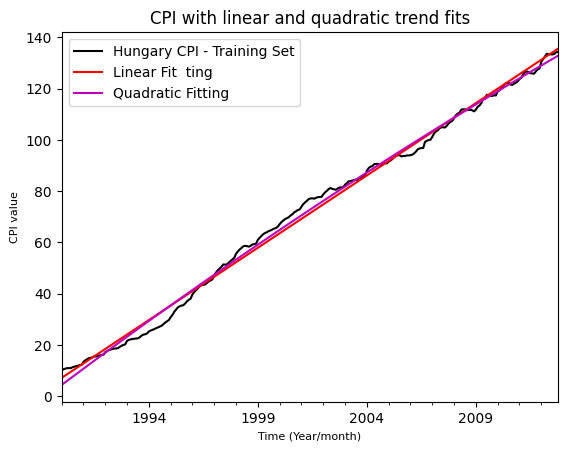

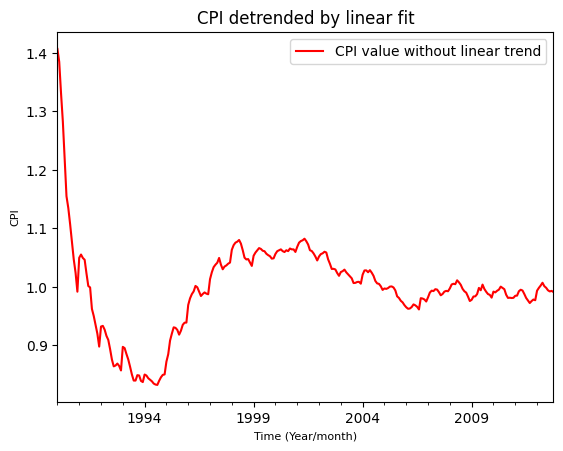

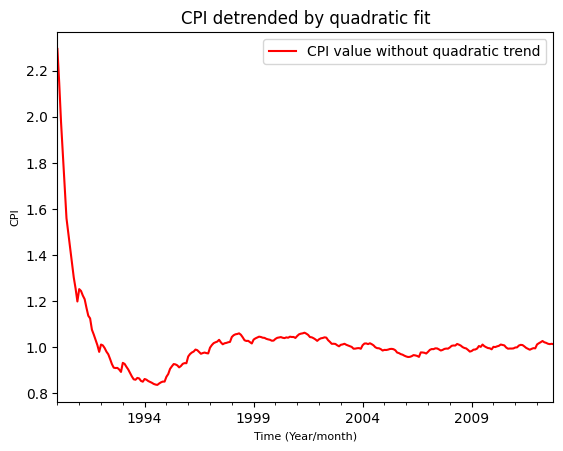

In [1139]:
tMonths = np.arange(len(train_TS))

# Linear trend estimation by fitting
coefs_lin = np.polyfit(tMonths, train_TS.values, 1)
linVals = np.polyval(coefs_lin, tMonths)
linTS = pd.Series(data=linVals, index=train_TS.index, name="Linear Fit  ting")

# Quadratic trend estimation by fitting
coefs_quad = np.polyfit(tMonths, train_TS.values, 2)
quadVals = np.polyval(coefs_quad, tMonths)
quadTS = pd.Series(data=quadVals, index=train_TS.index, name="Quadratic Fitting")

plt.figure()
ax = train_TS.plot(legend=True, color='k')
linTS.plot(ax=ax, legend=True, color='r')
quadTS.plot(ax=ax, legend=True, color='m')
ax.set_ylabel('CPI value', fontdict={'fontsize': 8})
ax.set_xlabel('Time (Year/month)', fontdict={'fontsize': 8})
ax.set_title('CPI with linear and quadratic trend fits')
plt.show()

# Remove linear trend
plt.figure()
ts_no_trend__lin_mult = train_TS / linTS
ts_no_trend__lin_mult.name = "CPI value without linear trend"
ax2 = ts_no_trend__lin_mult.plot(legend=True, color='r')
ax2.set_ylabel('CPI', fontdict={'fontsize': 8})
ax2.set_xlabel('Time (Year/month)', fontdict={'fontsize': 8})
ax2.set_title('CPI detrended by linear fit')
plt.show()

# Remove quadratic trend
plt.figure()
ts_no_trend__quad_mult = train_TS / quadTS
ts_no_trend__quad_mult.name = "CPI value without quadratic trend"
ax3 = ts_no_trend__quad_mult.plot(legend=True, color='r')
ax3.set_ylabel('CPI', fontdict={'fontsize': 8})
ax3.set_xlabel('Time (Year/month)', fontdict={'fontsize': 8})
ax3.set_title('CPI detrended by quadratic fit')
plt.show()

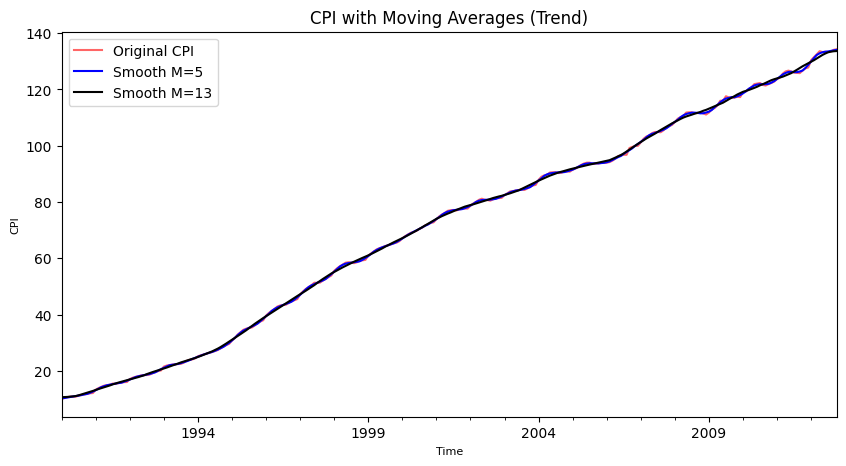

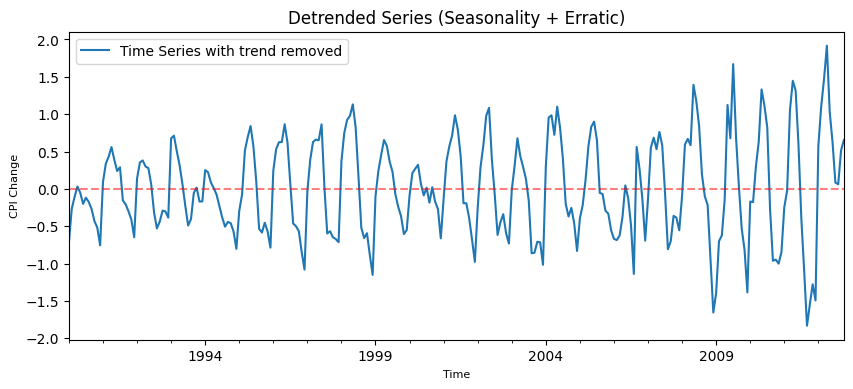

In [1140]:
def maSmooth(TSeries, omega, data_aug=False):
    M = omega.shape[0]
    lag = int(np.floor((M - 1) / 2))
    
    if data_aug: # Se a série suavizada deve ter o mesmo número de amostras
        # Substituímos .append por pd.concat
        left = pd.Series(np.flip(TSeries.iloc[0:lag].values), index=None) 
        right = pd.Series(np.flip(TSeries.iloc[-lag:].values), index=None)
        
        TSeriesAug = pd.concat([left, TSeries.reset_index(drop=True), right]).reset_index(drop=True)
    else:
        TSeriesAug = TSeries.reset_index(drop=True)
        
    nf = range(lag, TSeriesAug.size - lag)
    xf = np.zeros(TSeriesAug.size - 2 * lag).astype('float')
    
    for n in nf:
        # Seleciona a janela e multiplica pelos pesos (omega)
        window = TSeriesAug.iloc[n - lag : n + lag + 1].values
        xf[n - lag] = (1 / float(np.sum(omega))) * np.sum(np.multiply(window, omega))
    
    # Repomos o índice original da TSeries p gráfico bater certo
    xf = pd.Series(data=xf, index=TSeries.index, name="Smoothed TS with M=" + str(M))
    
    return xf

M_small = 5
omega5 = np.ones(M_small) * (1 / float(M_small))    
smooth5 = maSmooth(train_TS, omega5, data_aug=True)

M_large = 13
omega13 = np.ones(M_large) * (1 / float(M_large))
smooth13 = maSmooth(train_TS, omega13, data_aug=True)

# --- trend ---
plt.figure(figsize=(10, 5))
ax = train_TS.plot(color='r', label='Original CPI', alpha=0.6)
smooth5.plot(color='b', label=f'Smooth M={M_small}')
smooth13.plot(color='k', label=f'Smooth M={M_large}')
ax.set_ylabel('CPI', fontdict={'fontsize': 8})
ax.set_xlabel('Time', fontdict={'fontsize': 8})
plt.legend()
plt.title('CPI with Moving Averages (Trend)')
plt.show()

# --- Detrending ---
plt.figure(figsize=(10, 4))
# Escolhemos a média móvel de 13 para remover a tendência
ts_no_trend_smooth_addict = train_TS - smooth13
ts_no_trend_smooth_addict.name = "Time Series with trend removed"
ax = ts_no_trend_smooth_addict.plot(legend=True)
ax.set_ylabel('CPI Change', fontdict={'fontsize': 8})
ax.set_xlabel('Time', fontdict={'fontsize': 8})
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title('Detrended Series (Seasonality + Erratic)')
plt.show()

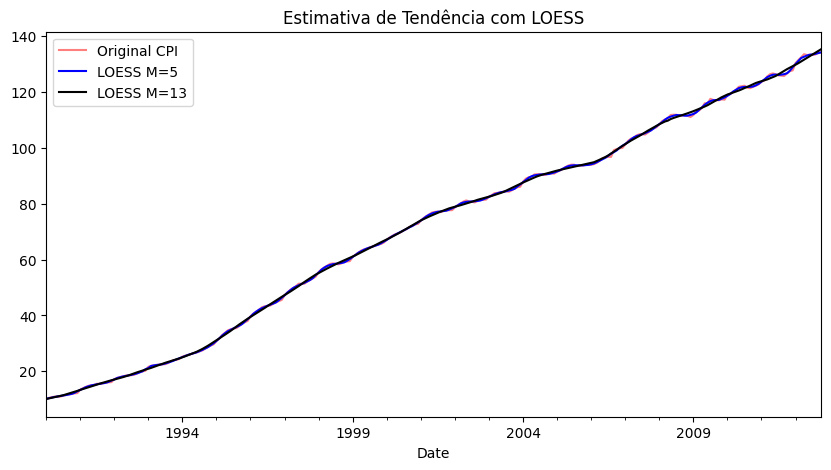

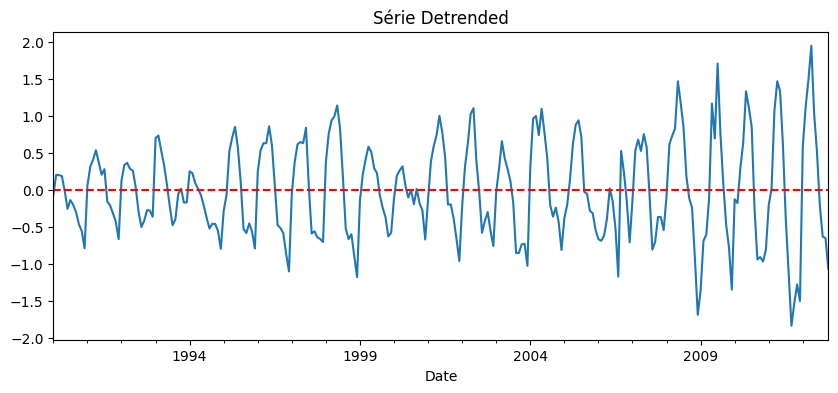

In [1141]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

def xWeights(x, xi, span):
    wi = (1 - abs((x - xi) / float(span))**3)**3
    return wi

def yWeights(ri, MAD):
    if np.abs(ri) < 6 * MAD:
        return (1 - ((ri / (6 * MAD))**2))**2
    else:
        return 0

def loessPass(TSeries, TSeriesE=None, span=5, timePass=True):
    lag = int((span - 1) / 2)
    xf = np.zeros(TSeries.size).astype('float')
    
    for k in range(TSeries.size):
        if k <= lag:
            win = TSeries.iloc[0:span]
            if not timePass: winE = TSeriesE.iloc[0:span]
            xvs = np.arange(span)
        elif k > TSeries.size - lag - 1:
            win = TSeries.iloc[TSeries.size - span : TSeries.size]
            if not timePass: winE = TSeriesE.iloc[TSeriesE.size - span : TSeriesE.size]
            xvs = np.arange(TSeries.size - span, TSeries.size)
        else:
            win = TSeries.iloc[k - lag : k + lag + 1]
            if not timePass: winE = TSeriesE.iloc[k - lag : k + lag + 1]
            xvs = np.arange(k - lag, k + lag + 1)

        ws = np.zeros(span).astype('float')
        
        if not timePass:
            res = np.array(win - winE)
            MAD = np.median(np.abs(res))
            if MAD == 0: MAD = 1e-6
            
        for xw in range(len(xvs)):
            if timePass:
                dist_max = np.max((np.abs(k - xvs[0]), np.abs(k - xvs[-1])))
                ws[xw] = xWeights(k, xvs[xw], dist_max if dist_max > 0 else 1)
            else:
                ws[xw] = yWeights(res[xw], MAD)
        
        exog = sm.add_constant(xvs)
        mod_wls = sm.WLS(win.values, exog, weights=ws)
        res_wls = mod_wls.fit()
        # Convertemos para array numpy p evitar o erro de AttributeError com iloc
        params = np.array(res_wls.params)
        xf[k] = params[1] * k + params[0]
        
    return xf

def lowess(TSeries, span=5):
    xf_initial = loessPass(TSeries, span=span, timePass=True)
    xf_final = loessPass(TSeries, TSeriesE=pd.Series(data=xf_initial, index=TSeries.index), span=span, timePass=False)
    return pd.Series(data=xf_final, index=TSeries.index, name="LOESS M=" + str(span))

M_val = 5
smooth5 = lowess(train_TS, span=M_val)

M_val = 13
smooth13 = lowess(train_TS, span=M_val)

# Tendência
plt.figure(figsize=(10,5))
ax = train_TS.plot(color='r', label='Original CPI', alpha=0.5)
smooth5.plot(color='b', label='LOESS M=5')
smooth13.plot(color='k', label='LOESS M=13')
plt.title("Estimativa de Tendência com LOESS")
plt.legend()
plt.show()

# Detrending (Sazonalidade + Ruído)
plt.figure(figsize=(10,4))
ts_no_trend_loess_addict = train_TS - smooth13 
ts_no_trend_loess_addict.plot(title="Série Detrended")
plt.axhline(0, color='red', linestyle='--')
plt.show()

O smoothing comportou-se muito melhor que o fitting para remover a tendência, o que também faz sentido já que a série original tinha flutuações e o fitting tende a ser rígido e assumir que a série cresce sempre da mesma forma.

## Perceber a sazonalidade

Text(0, 0.5, 'Normalized Power Spectrum (A.U.)')

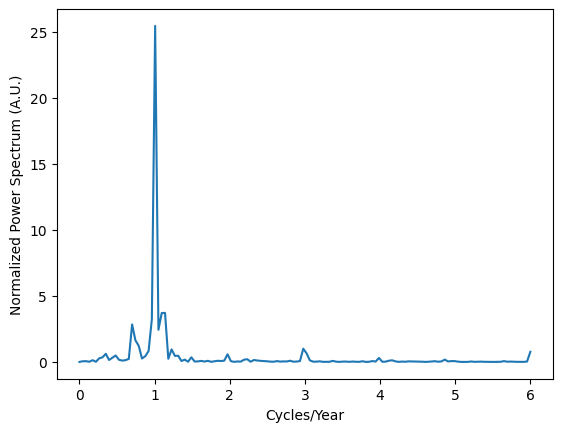

In [1142]:
fTS=(np.abs(np.fft.rfft(ts_no_trend_loess_addict-ts_no_trend_loess_addict.mean()))**2/ts_no_trend_loess_addict.size)# Mean was subtracted because 
#we want the evaluate the importance of the non-null frequency components

samp_freq=12 #12 samples/year
f=np.fft.rfftfreq(ts_no_trend_loess_addict.size, d=1/samp_freq)
plt.figure();
plt.plot(f,fTS)
plt.xlabel("Cycles/Year")
plt.ylabel("Normalized Power Spectrum (A.U.)")


O pico maior é em cerca de 1 pelo que podemos assumir um padrão de 12 meses, sendo que os outros picos são menores e irrelevantes.

Text(0.5, 0, 'Time (Years/Month)')

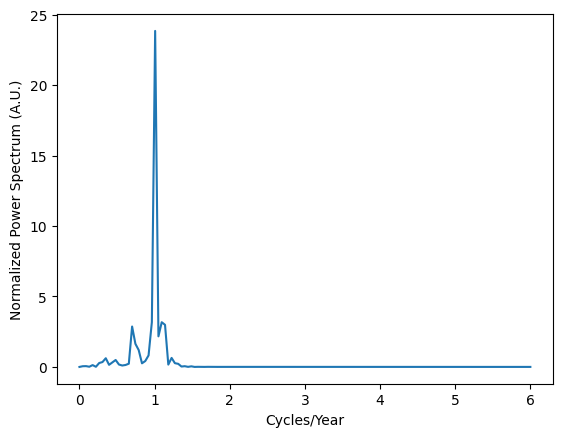

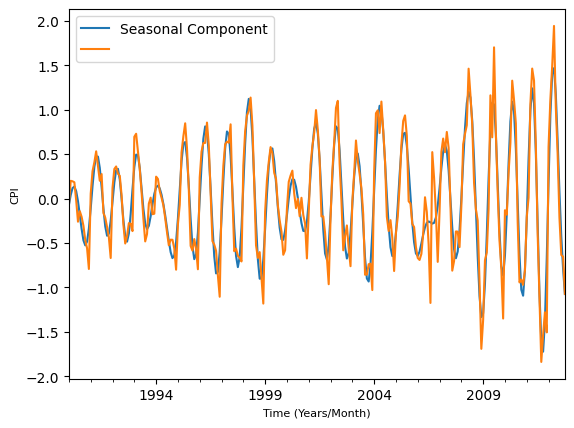

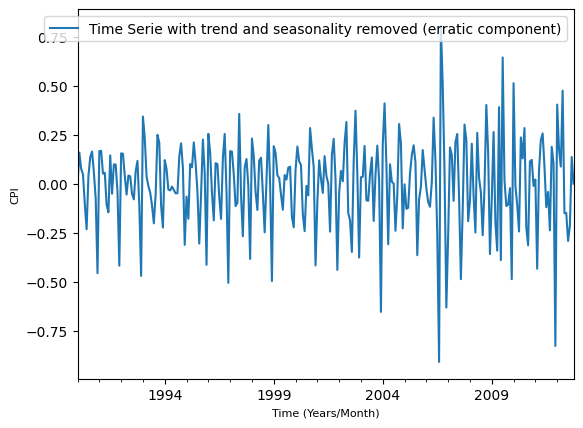

In [1143]:
sos = scs.butter(N=5, fs=12, Wn=1.4, btype='lowpass', output='sos')
Seasonal = scs.sosfiltfilt(sos, ts_no_trend_loess_addict.values)

#Lets look at the filter effect
fTS=(np.abs(np.fft.rfft(Seasonal-np.mean(Seasonal)))**2/ts_no_trend_loess_addict.size)

samp_freq=12 #12 samples/year
f=np.fft.rfftfreq(ts_no_trend_loess_addict.size, d=1/samp_freq)
plt.figure();
plt.plot(f,fTS)
plt.xlabel("Cycles/Year")
plt.ylabel("Normalized Power Spectrum (A.U.)")

SeaTS=pd.Series(data=Seasonal,index=train_TS.index,name="Seasonal Component")
plt.figure()
SeaTS.plot(legend=True)
ax=ts_no_trend_loess_addict.plot(legend=True)
ax.set_ylabel('CPI',fontdict={'fontsize':8})
ax.set_xlabel('Time (Years/Month)',fontdict={'fontsize':8})

psNoTrendNoSeas=ts_no_trend_loess_addict - SeaTS
psNoTrendNoSeas.name="Time Serie with trend and seasonality removed (erratic component)"

plt.figure()
ax=psNoTrendNoSeas.plot(legend=True)
ax.set_ylabel('CPI',fontdict={'fontsize':8})
ax.set_xlabel('Time (Years/Month)',fontdict={'fontsize':8})



Com um filtro passa-baixo, já obtivemos uma sequência que podemos aceitar como a componente errática. Supostamente, a série neste momento já seria estacionária mas vamos confirmar com o teste ADF.

In [1144]:
result=st.adfuller(psNoTrendNoSeas.dropna())

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -12.100272
p-value: 0.000000
Critical Values:
	1%: -3.456
	5%: -2.873
	10%: -2.573


O teste Augmented Dickey-Fuller resultou numa estatística de -12.10, valor este inferior ao valor crítico de 1% (-3.456), e num p-value arredonado a 0. Estes resultados permitem rejeitar a hipótese nula de existência de uma raiz unitária, confirmando que a série é estacionária.

<Figure size 1000x400 with 0 Axes>

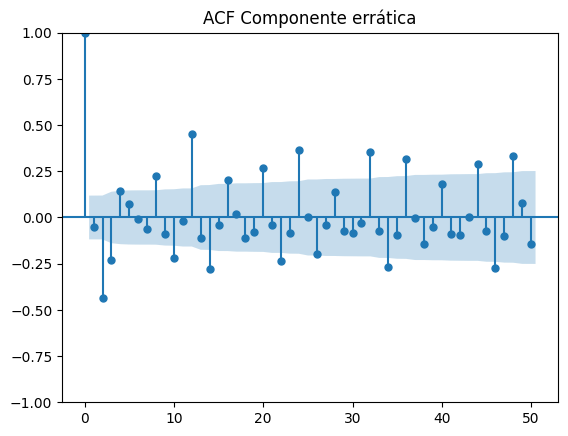

In [1145]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10, 4))
plot_acf(psNoTrendNoSeas, alpha=0.05, lags= 50)
plt.title("ACF Componente errática")
plt.show()

Apesar de pelo critério ADF, a componente errática ser estacionária, a autocorrelação cai logo no primeiro lag mas não "morre", continua a oscilar, então, talvez o filtro tenha deixado passar variações que não são puramente aleatórias.

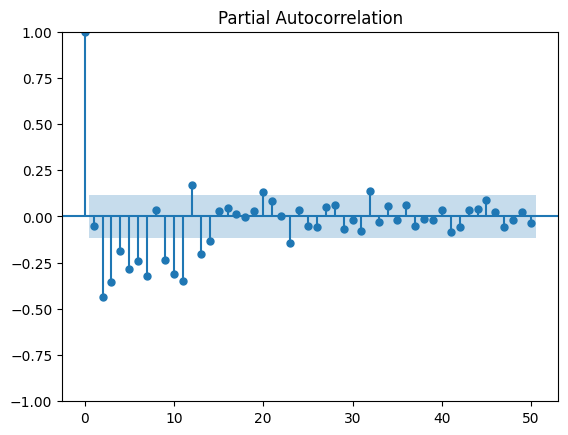

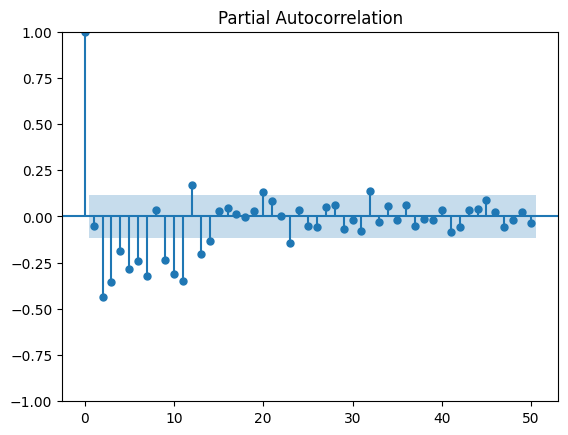

In [1146]:
plot_pacf(psNoTrendNoSeas, lags=50)

## Tentar estacionar a série com diferenciação

Text(0.5, 23.52222222222222, 'Time (Year')

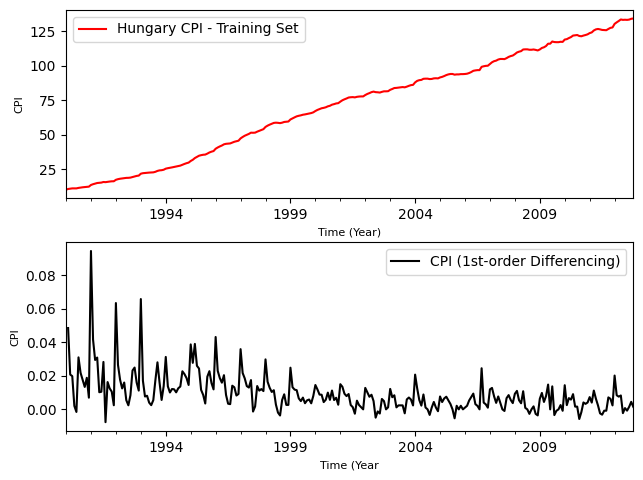

In [1147]:
fig, axs=plt.subplots(2)
fig.tight_layout()
train_TS.plot(ax=axs[0],legend=True,color='r')
axs[0].set_ylabel('CPI',fontdict={'fontsize':8})
axs[0].set_xlabel('Time (Year)',fontdict={'fontsize':8})

ts_diff1=np.log(train_TS).diff()
ts_diff1.name="CPI (1st-order Differencing)"
ts_diff1.plot(ax=axs[1],legend=True,color='k')
axs[1].set_ylabel('CPI',fontdict={'fontsize':8})
axs[1].set_xlabel('Time (Year',fontdict={'fontsize':8})

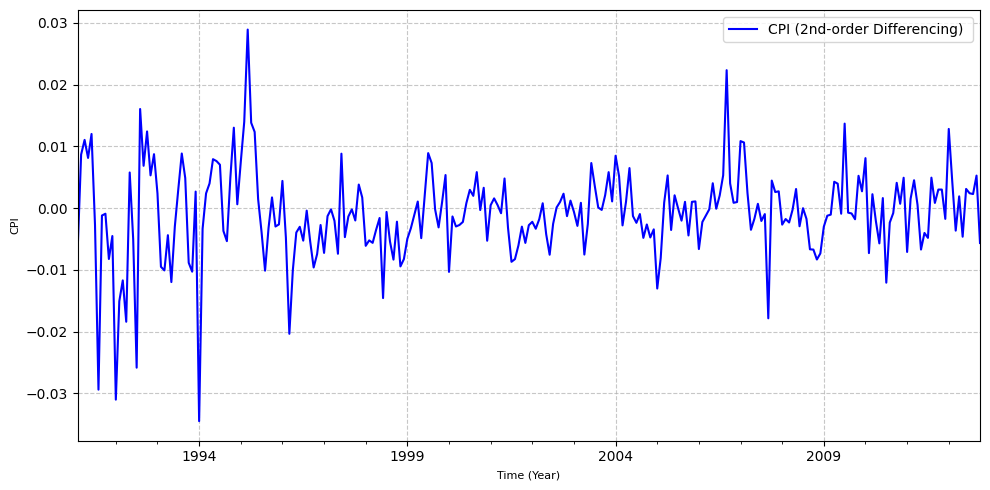

In [1148]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))

ts_diff2 = ts_diff1.diff(12).dropna()
ts_diff2.name = "CPI (2nd-order Differencing) "
ts_diff2.plot(ax=axs, legend=True, color='b')
axs.set_ylabel('CPI', fontdict={'fontsize': 8})
axs.set_xlabel('Time (Year)', fontdict={'fontsize': 8})
axs.grid(True, linestyle='--', alpha=0.7)
fig.tight_layout()
plt.show()

<Figure size 1000x400 with 0 Axes>

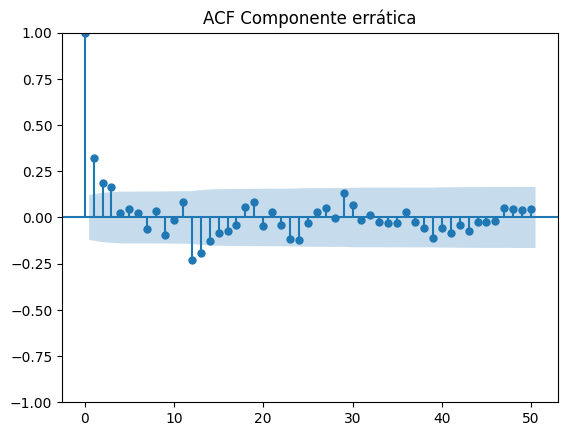

In [1149]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10, 4))
plot_acf(ts_diff2, alpha=0.05, lags=50)
plt.title("ACF Componente errática")
plt.show()

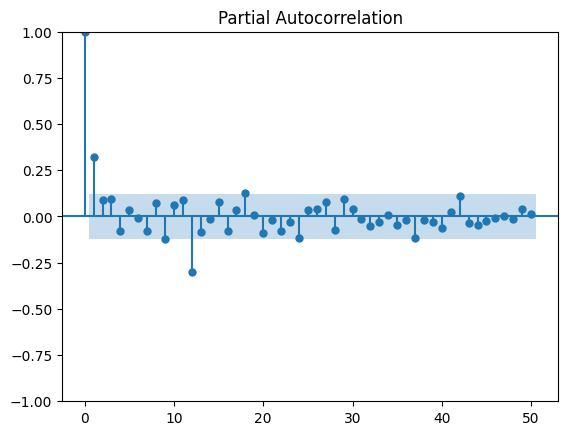

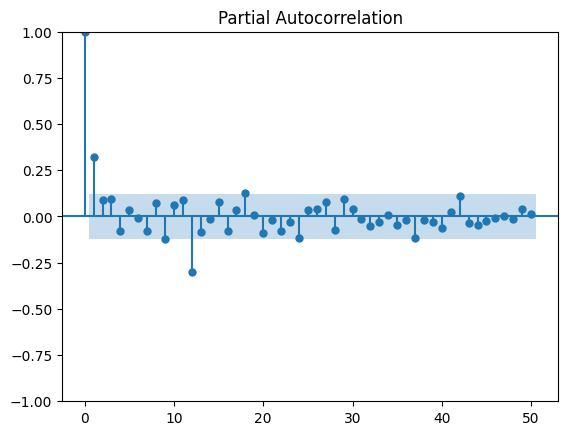

In [1150]:
plot_pacf(ts_diff2, lags=50)

In [1151]:
result=st.adfuller(ts_diff2.dropna())

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -6.093700
p-value: 0.000000
Critical Values:
	1%: -3.457
	5%: -2.873
	10%: -2.573


Nem com diferenciação com ordem 2 a autocorrelação morreu pelo que claramente a série ainda tem memória e ainda é um processo correlacionado.

## Modelo multiplicativo

Apesar de inicialmente termos assumido um modelo aditivo porque parecia ser melhor, ele não está a mostrar conseguir aproximar a componente errática a ruído branco pelo que vamos tentar aplicar as mesmas técnicas que usámos com o modelo aditivo mas com um multiplicativo.

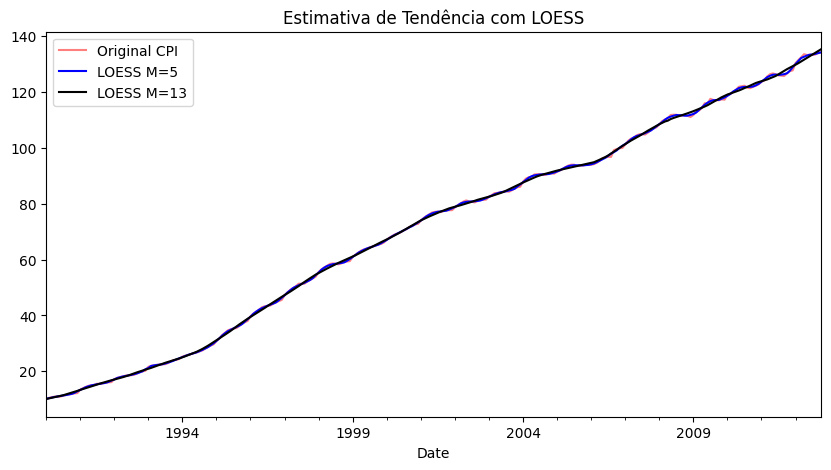

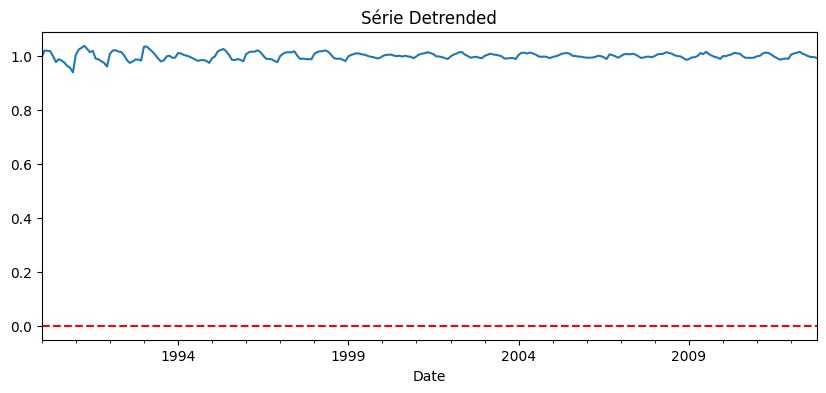

In [1152]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

def xWeights(x, xi, span):
    wi = (1 - abs((x - xi) / float(span))**3)**3
    return wi

def yWeights(ri, MAD):
    if np.abs(ri) < 6 * MAD:
        return (1 - ((ri / (6 * MAD))**2))**2
    else:
        return 0

def loessPass(TSeries, TSeriesE=None, span=5, timePass=True):
    lag = int((span - 1) / 2)
    xf = np.zeros(TSeries.size).astype('float')
    
    for k in range(TSeries.size):
        if k <= lag:
            win = TSeries.iloc[0:span]
            if not timePass: winE = TSeriesE.iloc[0:span]
            xvs = np.arange(span)
        elif k > TSeries.size - lag - 1:
            win = TSeries.iloc[TSeries.size - span : TSeries.size]
            if not timePass: winE = TSeriesE.iloc[TSeriesE.size - span : TSeriesE.size]
            xvs = np.arange(TSeries.size - span, TSeries.size)
        else:
            win = TSeries.iloc[k - lag : k + lag + 1]
            if not timePass: winE = TSeriesE.iloc[k - lag : k + lag + 1]
            xvs = np.arange(k - lag, k + lag + 1)

        ws = np.zeros(span).astype('float')
        
        if not timePass:
            res = np.array(win - winE)
            MAD = np.median(np.abs(res))
            if MAD == 0: MAD = 1e-6
            
        for xw in range(len(xvs)):
            if timePass:
                dist_max = np.max((np.abs(k - xvs[0]), np.abs(k - xvs[-1])))
                ws[xw] = xWeights(k, xvs[xw], dist_max if dist_max > 0 else 1)
            else:
                ws[xw] = yWeights(res[xw], MAD)
        
        exog = sm.add_constant(xvs)
        mod_wls = sm.WLS(win.values, exog, weights=ws)
        res_wls = mod_wls.fit()
        # Convertemos para array numpy p evitar o erro de AttributeError com iloc
        params = np.array(res_wls.params)
        xf[k] = params[1] * k + params[0]
        
    return xf

def lowess(TSeries, span=5):
    xf_initial = loessPass(TSeries, span=span, timePass=True)
    xf_final = loessPass(TSeries, TSeriesE=pd.Series(data=xf_initial, index=TSeries.index), span=span, timePass=False)
    return pd.Series(data=xf_final, index=TSeries.index, name="LOESS M=" + str(span))

M_val = 5
smooth5 = lowess(train_TS, span=M_val)

M_val = 13
smooth13 = lowess(train_TS, span=M_val)

# Tendência
plt.figure(figsize=(10,5))
ax = train_TS.plot(color='r', label='Original CPI', alpha=0.5)
smooth5.plot(color='b', label='LOESS M=5')
smooth13.plot(color='k', label='LOESS M=13')
plt.title("Estimativa de Tendência com LOESS")
plt.legend()
plt.show()

# Detrending (Sazonalidade + Ruído)
plt.figure(figsize=(10,4))
ts_no_trend_loess_mult = train_TS / smooth13 
ts_no_trend_loess_mult.plot(title="Série Detrended")
plt.axhline(0, color='red', linestyle='--')
plt.show()

Text(0, 0.5, 'Normalized Power Spectrum (A.U.)')

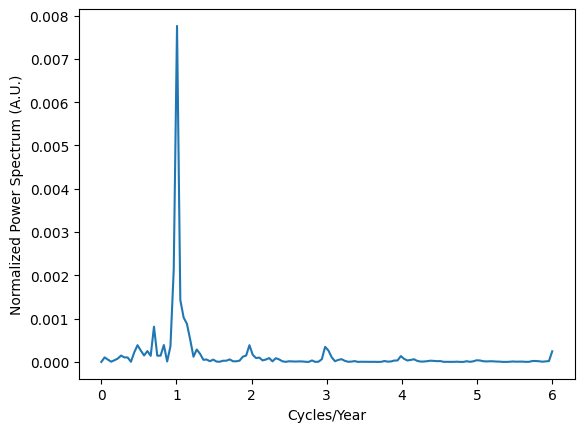

In [1153]:
fTS=(np.abs(np.fft.rfft(ts_no_trend_loess_mult-ts_no_trend_loess_mult.mean()))**2/ts_no_trend_loess_mult.size)# Mean was subtracted because 

samp_freq=12 #12 samples/year
f=np.fft.rfftfreq(ts_no_trend_loess_mult.size, d=1/samp_freq)
plt.figure();
plt.plot(f,fTS)
plt.xlabel("Cycles/Year")
plt.ylabel("Normalized Power Spectrum (A.U.)")


Text(0.5, 0, 'Time (Years/Month)')

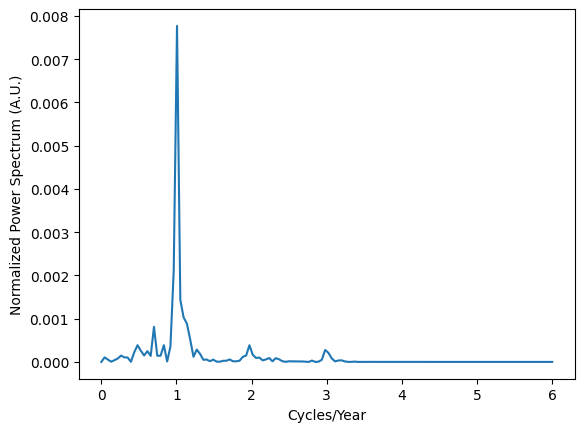

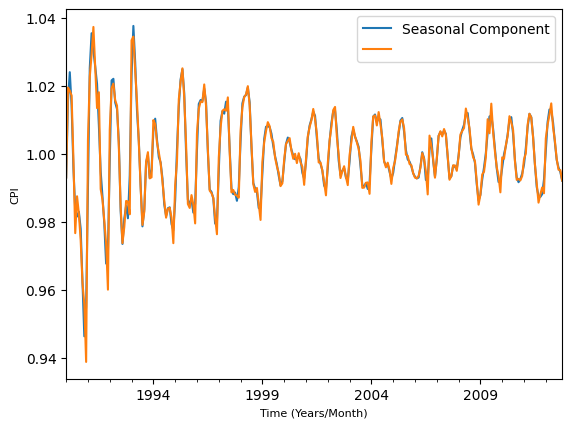

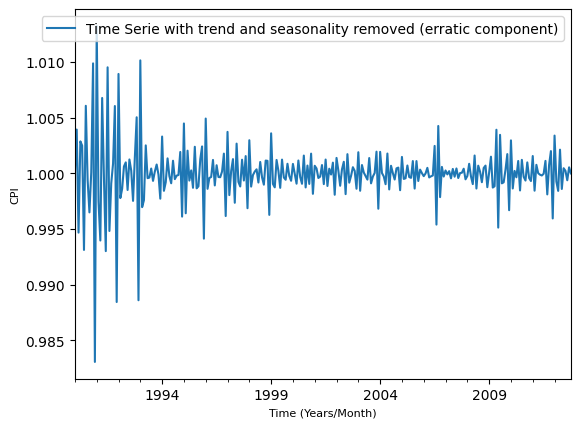

In [1154]:
sos = scs.butter(N=5, fs=12, Wn=3.4, btype='lowpass', output='sos')
Seasonal = scs.sosfiltfilt(sos, ts_no_trend_loess_mult.values)

#Lets look at the filter effect
fTS=(np.abs(np.fft.rfft(Seasonal-np.mean(Seasonal)))**2/ts_no_trend_loess_mult.size)

samp_freq=12 #12 samples/year
f=np.fft.rfftfreq(ts_no_trend_loess_mult.size, d=1/samp_freq)
plt.figure();
plt.plot(f,fTS)
plt.xlabel("Cycles/Year")
plt.ylabel("Normalized Power Spectrum (A.U.)")

SeaTS=pd.Series(data=Seasonal,index=train_TS.index,name="Seasonal Component")
plt.figure()
SeaTS.plot(legend=True)
ax=ts_no_trend_loess_mult.plot(legend=True)
ax.set_ylabel('CPI',fontdict={'fontsize':8})
ax.set_xlabel('Time (Years/Month)',fontdict={'fontsize':8})

psNoTrendNoSeas_mult=ts_no_trend_loess_mult / SeaTS
psNoTrendNoSeas_mult.name="Time Serie with trend and seasonality removed (erratic component)"

plt.figure()
ax=psNoTrendNoSeas_mult.plot(legend=True)
ax.set_ylabel('CPI',fontdict={'fontsize':8})
ax.set_xlabel('Time (Years/Month)',fontdict={'fontsize':8})



In [1155]:
result=st.adfuller(psNoTrendNoSeas_mult.dropna())

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -5.882907
p-value: 0.000000
Critical Values:
	1%: -3.456
	5%: -2.873
	10%: -2.573


<Figure size 1000x400 with 0 Axes>

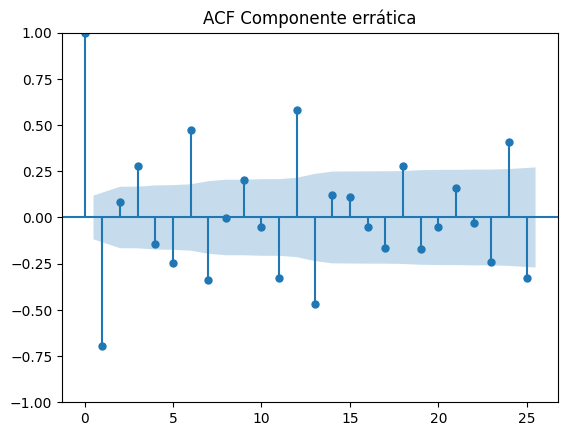

In [1156]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10, 4))
plot_acf(psNoTrendNoSeas_mult, alpha=0.05)
plt.title("ACF Componente errática")
plt.show()

Claramente, o modelo multiplicativo não é adequado já que no gráfico da componente errática vemos sazonalidade.

## Usar módulo de uma biblioteca para decompor 

In [1157]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(train_TS, model='additive', period=12)
trend = decomp.trend
seasonal = decomp.seasonal
residual = decomp.resid

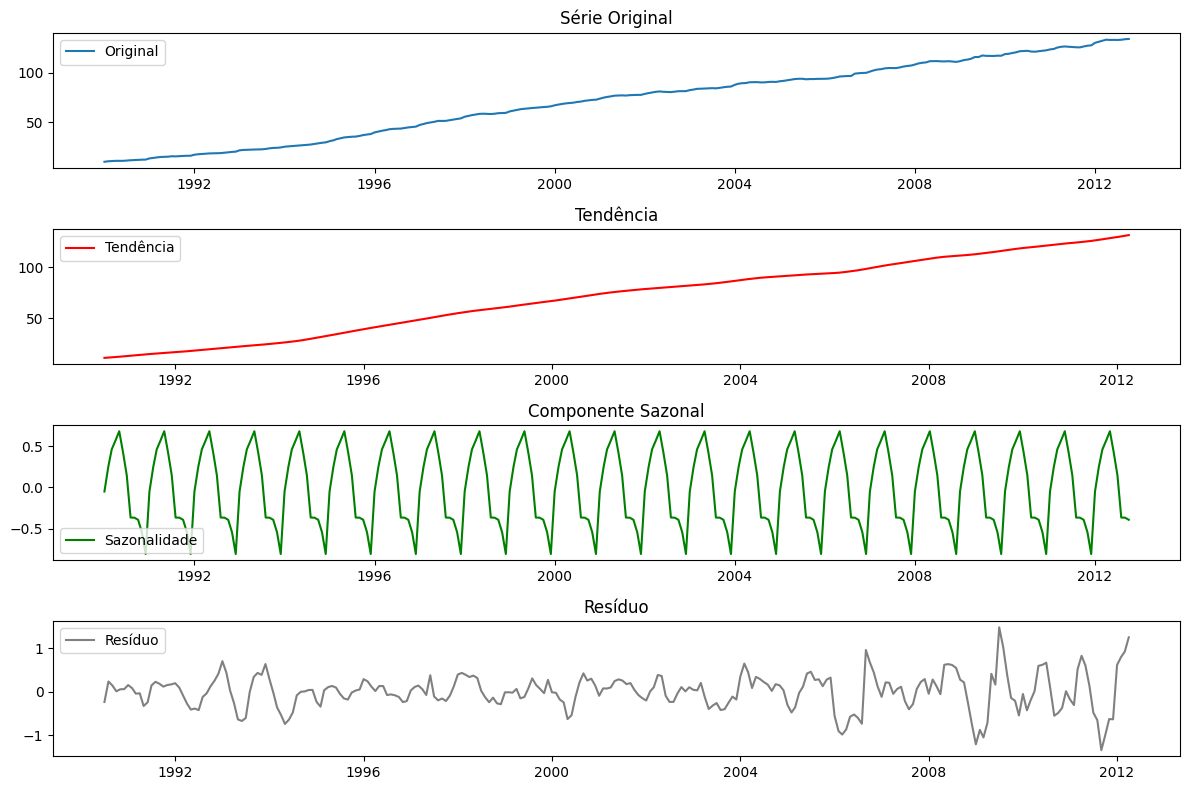

In [1158]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(train_TS, label='Original')
plt.legend(loc='best')
plt.title('Série Original')

plt.subplot(412)
plt.plot(trend, label='Tendência', color='red')
plt.legend(loc='best')
plt.title('Tendência')

plt.subplot(413)
plt.plot(seasonal, label='Sazonalidade', color='green')
plt.legend(loc='best')
plt.title('Componente Sazonal')

plt.subplot(414)
plt.plot(residual, label='Resíduo', color='gray')
plt.legend(loc='best')
plt.title('Resíduo')

plt.tight_layout()
plt.show()

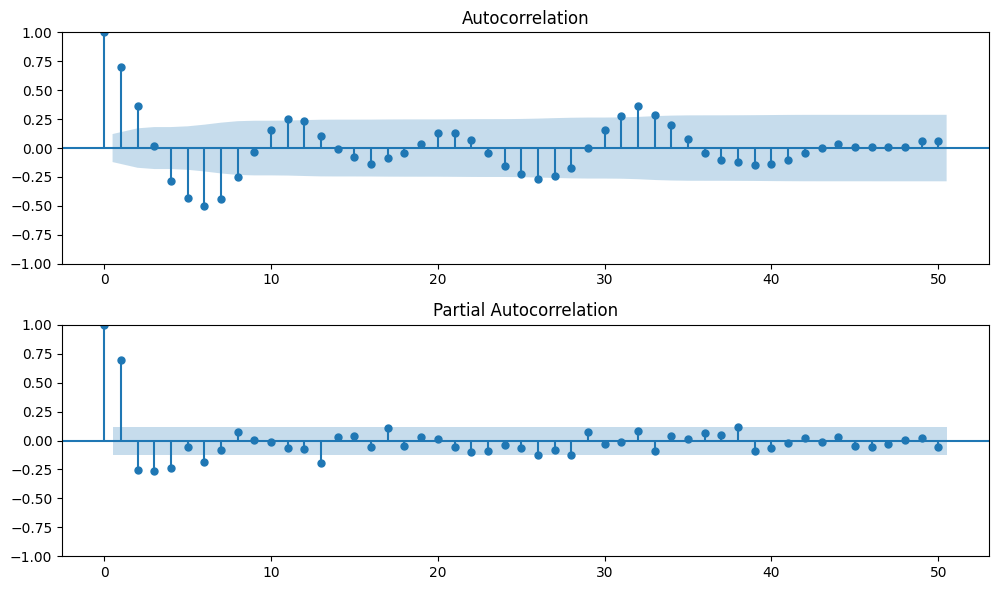

In [1159]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

resid_clean = residual.dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(resid_clean, lags=50, ax=ax1)
plot_pacf(resid_clean, lags=50, ax=ax2)
plt.tight_layout()
plt.show()

In [1160]:
result=st.adfuller(resid_clean.dropna())

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -4.221013
p-value: 0.000607
Critical Values:
	1%: -3.457
	5%: -2.873
	10%: -2.573
